In [1]:
# Imports

import torch
from torch import randperm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import itertools
import numpy as np
from PIL import Image

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    
])

dataset = datasets.ImageFolder(root = "../data/brain_tumor_dataset", transform=transform)

loader = DataLoader(dataset,
                    batch_size=32,
                    shuffle=True)

train_size = int(0.8*len(dataset))
val_size = int(0.1*len(dataset))
test_size = len(dataset) - val_size - train_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size], 
                                            generator=torch.Generator().manual_seed(8))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

In [3]:
# TODO : Use gradual unfreezing approach on 3-4 models. Should be pretty straightforward to do this

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _freeze_all(model: nn.Module):
    """Freeze every parameter in the model."""
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_all(model: nn.Module, optimizer, new_lr: float):
    """
    Unfreeze every parameter and update the optimizer.
    Instead of adding a new group (which causes duplicates),
    we collect only the params NOT already in the optimizer.
    """
    # Collect params already registered in the optimizer
    already_in_optimizer = set()
    for group in optimizer.param_groups:
        for p in group["params"]:
            already_in_optimizer.add(id(p))

    # Unfreeze everything and collect the new params
    new_params = []
    for param in model.parameters():
        param.requires_grad = True
        if id(param) not in already_in_optimizer:
            new_params.append(param)

    model = model.to(DEVICE)

    # Only add params that aren't already tracked
    if new_params:
        optimizer.add_param_group({"params": new_params, "lr": new_lr})
        print(f"[Unfreeze] {len(new_params)} parameter groups unfrozen — new LR: {new_lr}")
    else:
        print("[Unfreeze] No new params to add — already fully unfrozen")

In [ ]:
NUM_CLASSES = 4          # adjust to match your dataset
NUM_EPOCHS  = 10
LR_HEAD     = 1e-3       # learning rate when only the head is unfrozen
LR_FULL     = 1e-4       # learning rate after full unfreezing (lower to protect pretrained weights)
UNFREEZE_EPOCH = 5       # epoch at which all layers are unfrozen


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for img, lbl in loader:
        img, lbl = img.to(DEVICE, non_blocking=True), lbl.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(img)
            loss = criterion(outputs, lbl)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * img.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(lbl).sum().item()
        total += lbl.size(0)

    return running_loss / total, correct / total
        


In [5]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import torch.nn.functional as F

def evaluate(model, loader, criterion, num_classes, k=2):

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    top_k_correct = 0

    all_probs   = []   # softmax probabilities  (for AUC)
    all_preds   = []   # argmax predictions      (for F1, confusion matrix)
    all_labels  = []   # ground truth            (for everything)

    with torch.no_grad():
        for img, lbl in loader:
            img, lbl = img.to(DEVICE), lbl.to(DEVICE)
            outputs = model(img)
            loss = criterion(outputs, lbl)

            running_loss += loss.item() * img.size(0)   # ← bug fix: loss.item() not loss.item

            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            # Top-1 accuracy
            correct += predicted.eq(lbl).sum().item()
            total   += lbl.size(0)                      # ← bug fix: lbl.size(0) not lbl.size()

            # Top-K accuracy
            top_k_correct += (outputs.topk(k, dim=1).indices == lbl.unsqueeze(1)).any(dim=1).sum().item()

            all_probs.append(probs.cpu())
            all_preds.append(predicted.cpu())
            all_labels.append(lbl.cpu())

    all_probs  = torch.cat(all_probs).numpy()
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    avg_loss = running_loss / total
    acc      = correct / total
    top_k    = top_k_correct / total
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    f1       = f1_score(all_labels, all_preds, average='weighted')
    cm       = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, top_k, auc, f1, cm, all_probs, all_labels

In [6]:
from sklearn.metrics import roc_auc_score

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import torch.nn as nn

model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

_freeze_all(model)

# Replace classifier (last layer)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 4)
model = model.to(DEVICE)
model = torch.compile(model)


criterion = nn.CrossEntropyLoss()

# TODO : Refresher
optimizer = optim.Adam(
    filter(lambda p : p.requires_grad, model.parameters()),
    lr = LR_HEAD
)

# TODO : What is this
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

scaler = torch.amp.GradScaler('cuda')

best_val_acc = 0.0
unfrozen = False

# Tracking arrays
train_losses = []
eff_val_losses = []
eff_val_accs = []
eff_val_aucs = []       # AUC-ROC: measures model's ability to distinguish between classes
                    # Range: 0.5 (random) → 1.0 (perfect)
                    # Unlike accuracy, it's threshold-independent and handles class imbalance well

for epoch in range(NUM_EPOCHS):

    if epoch == UNFREEZE_EPOCH and not unfrozen:
        unfreeze_all(model, optimizer, LR_FULL)
        unfrozen = True
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)  # reset


    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, scaler)

    eff_val_loss, eff_val_acc, eff_val_top_k, eff_val_auc, eff_val_f1, eff_val_cm, eff_val_probs, eff_val_labels = evaluate(
        model, val_loader, criterion, num_classes=NUM_CLASSES
    )

    train_losses.append(train_loss)
    eff_val_losses.append(eff_val_loss)
    eff_val_accs.append(eff_val_acc)
    eff_val_aucs.append(eff_val_auc)

    print(f"  val_loss: {eff_val_loss:.4f} | val_acc: {eff_val_acc:.4f} | "
          f"AUC: {eff_val_auc:.4f} | F1: {eff_val_f1:.4f}")

    scheduler.step(eff_val_loss)

Epoch 0/10


C:\Users\Trevo\AppData\Local\Temp\ipykernel_35372\729586554.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  val_loss: 20.3813 | val_acc: 0.8519 | AUC: 0.9558 | F1: 0.8505
Epoch 1/10


C:\Users\Trevo\AppData\Local\Temp\ipykernel_35372\729586554.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  val_loss: 29.9770 | val_acc: 0.8732 | AUC: 0.9705 | F1: 0.8708
Epoch 2/10


...

  val_loss: 104.8387 | val_acc: 0.9744 | AUC: 0.9961 | F1: 0.9745
Epoch 8/10


C:\Users\Trevo\AppData\Local\Temp\ipykernel_35372\729586554.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  val_loss: 16.2675 | val_acc: 0.9801 | AUC: 0.9917 | F1: 0.9801
Epoch 9/10


C:\Users\Trevo\AppData\Local\Temp\ipykernel_35372\729586554.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  val_loss: 29.8835 | val_acc: 0.9843 | AUC: 0.9917 | F1: 0.9843


In [30]:
import time

start = time.time()
for imgs, labels in train_loader:
    imgs = imgs.to(DEVICE)
    break
print(f"First batch load time: {time.time() - start:.2f}s")

First batch load time: 10.42s


In [11]:
eff_val_losses

[20.381339180248755,
 29.97699919767529,
 39.327965921656016,
 80.62830255051114,
 45.47668407997514,
 47.367382696837694,
 102.62465018903747,
 104.83867265957214,
 16.267525027981,
 29.88353068386722]

In [12]:
eff_val_f1

0.9843456860471279

In [7]:
test_loss, test_acc, val_top_k, test_auc, test_f1, test_cm, test_probs, test_labels = evaluate(
    model, test_loader, criterion, num_classes=NUM_CLASSES
)

test_acc

0.9800853485064012

In [8]:
test_cm

array([[155,   0,   2,   0],
       [  3, 204,   2,   1],
       [  0,   0, 156,   6],
       [  0,   0,   0, 174]])

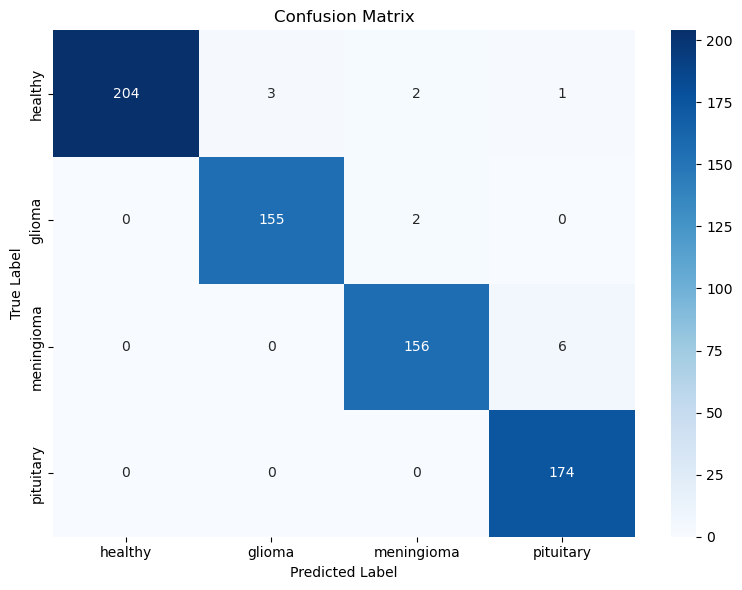

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["healthy", "glioma", "meningioma", "pituitary"]  # swapped index 0 and 1

# Swap rows 0 and 1, then columns 0 and 1
swap = [1, 0, 2, 3]
swapped_cm = test_cm[np.ix_(swap, swap)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    swapped_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()